In [122]:
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [123]:
with zipfile.ZipFile(r"C:\Users\yapri\Downloads\archive (1).zip") as zip_file:
    print(zip_file.namelist())

['student_performance.csv']


In [124]:
with zipfile.ZipFile(r"C:\Users\yapri\Downloads\archive (1).zip") as zip_file:
    
    with zip_file.open('student_performance.csv')as file:
        data=pd.read_csv(file)    

In [125]:
data.drop(columns=["student_id","grade"], inplace=True)

In [126]:
data.shape

(1000000, 4)

In [127]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   weekly_self_study_hours  1000000 non-null  float64
 1   attendance_percentage    1000000 non-null  float64
 2   class_participation      1000000 non-null  float64
 3   total_score              1000000 non-null  float64
dtypes: float64(4)
memory usage: 30.5 MB


In [128]:
data.describe()

,weekly_self_study_hours,attendance_percentage,class_participation,total_score
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,15.029127,84.711046,5.985203,84.283845
std,6.899431,9.424143,1.956421,15.432969
min,0.000000,50.000000,0.000000,9.400000
25%,10.300000,78.300000,4.700000,73.900000
50%,15.000000,85.000000,6.000000,87.500000
75%,19.700000,91.800000,7.300000,100.000000
max,40.000000,100.000000,10.000000,100.000000


In [129]:
data.isnull().sum()

weekly_self_study_hours    0
attendance_percentage      0
class_participation        0
total_score                0
dtype: int64

In [130]:
data.head()

,weekly_self_study_hours,attendance_percentage,class_participation,total_score
0,18.5,95.6,3.8,97.9
1,14.0,80.0,2.5,83.9
2,19.5,86.3,5.3,100.0
3,25.7,70.2,7.0,100.0
4,13.4,81.9,6.9,92.0


In [131]:
data.duplicated().sum()

17871

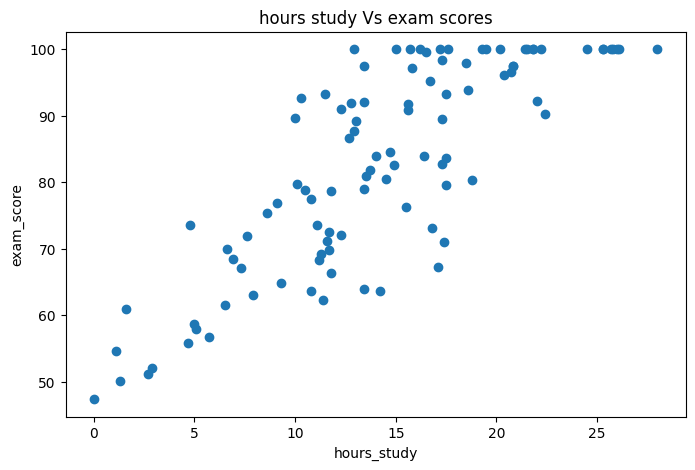

In [132]:
plt.figure(figsize=(8,5))
plt.scatter(data["weekly_self_study_hours"][:100],data["total_score"][:100])
plt.xlabel("hours_study")
plt.ylabel("exam_score")
plt.title("hours study Vs exam scores")
plt.show()

In [133]:
sample_df=data.sample(3500,random_state=42)

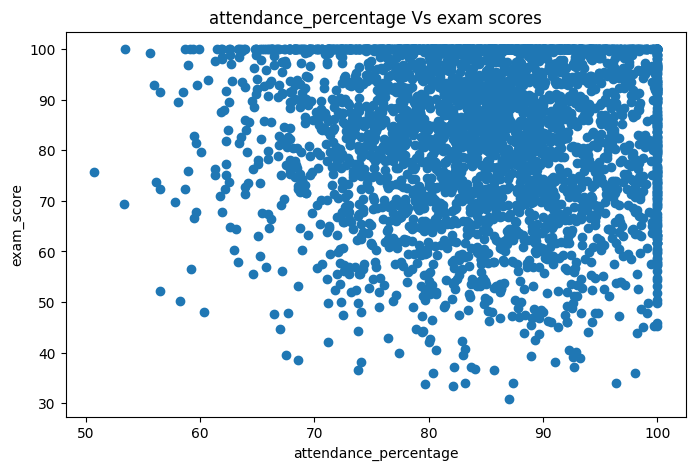

In [134]:
plt.figure(figsize=(8,5))
plt.scatter(sample_df["attendance_percentage"],sample_df["total_score"])
plt.xlabel("attendance_percentage")
plt.ylabel("exam_score")
plt.title("attendance_percentage Vs exam scores")
plt.show()

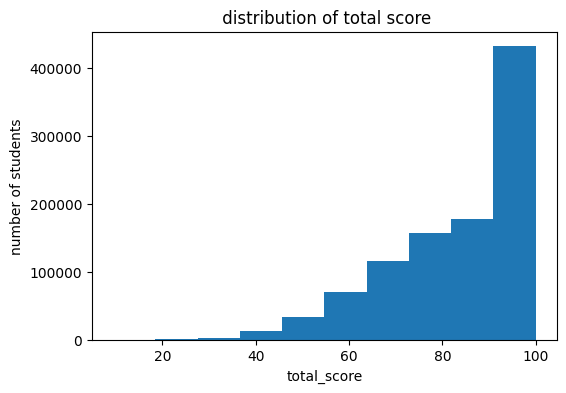

In [135]:
plt.figure(figsize=(6,4))
plt.hist(data['total_score'])
plt.xlabel("total_score")
plt.ylabel("number of students")
plt.title(" distribution of total score")
plt.show()

In [136]:
data["attendance_percentage"].corr(data["total_score"])

-0.0010138159883893475

In [137]:
data.corr(numeric_only=True)

,weekly_self_study_hours,attendance_percentage,class_participation,total_score
weekly_self_study_hours,1.000000,-0.001008,0.001244,0.812241
attendance_percentage,-0.001008,1.000000,-0.000043,-0.001014
class_participation,0.001244,-0.000043,1.000000,0.000684
total_score,0.812241,-0.001014,0.000684,1.000000


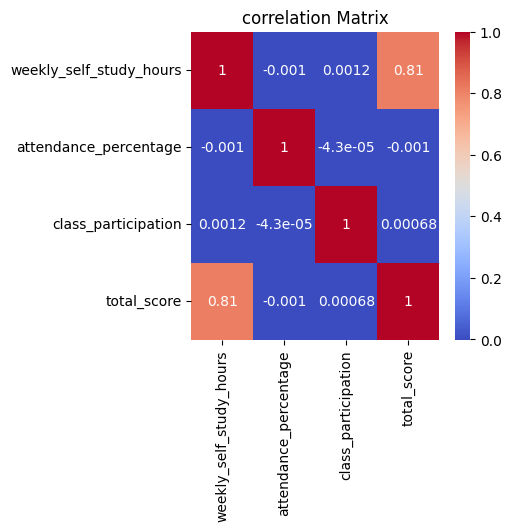

In [138]:
import seaborn as sns
plt.figure(figsize=(4,4))
sns.heatmap(data.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.title("correlation Matrix")
plt.show()

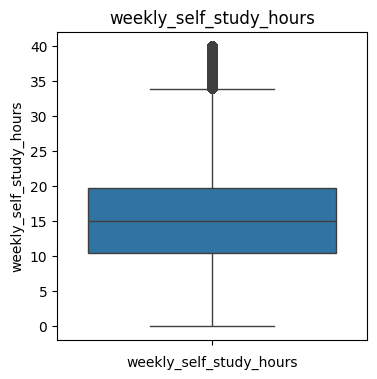

In [139]:
plt.figure(figsize=(4,4))
sns.boxplot(data["weekly_self_study_hours"])
plt.title("weekly_self_study_hours")
plt.xlabel("weekly_self_study_hours")
plt.show()

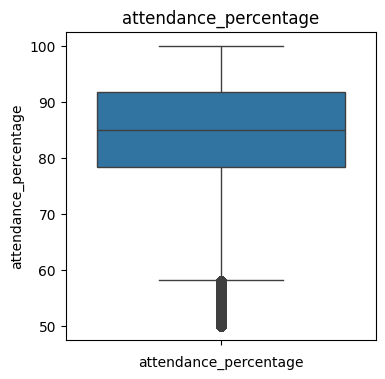

In [140]:
plt.figure(figsize=(4,4))
sns.boxplot(data["attendance_percentage"])
plt.title("attendance_percentage")
plt.xlabel("attendance_percentage")
plt.show()

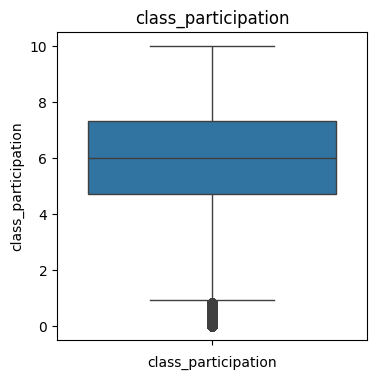

In [141]:
plt.figure(figsize=(4,4))
sns.boxplot(data["class_participation"])
plt.title("class_participation")
plt.xlabel("class_participation")
plt.show()

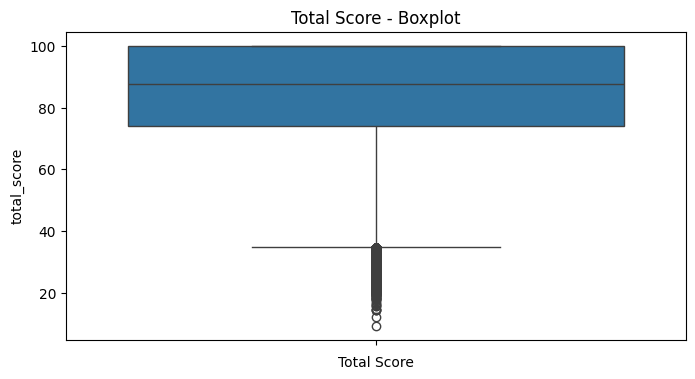

In [142]:
plt.figure(figsize=(8, 4))
sns.boxplot(data["total_score"])
plt.title("Total Score - Boxplot")
plt.xlabel("Total Score")
plt.show()

In [143]:
q1=data["weekly_self_study_hours"].quantile(0.25)
q3=data["weekly_self_study_hours"].quantile(0.75)
iqr=q3-q1
lower=q1-(1.5*(iqr))
upper=q3 +(1.5*(iqr))
print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower Bound:", lower)
print("Upper Bound:", upper)

Q1: 10.3
Q3: 19.7
IQR: 9.399999999999999
Lower Bound: -3.799999999999997
Upper Bound: 33.8


In [144]:
outlier=data[data["weekly_self_study_hours"]>upper]
print("Number of potential outliers:", len(outlier))

Number of potential outliers: 3541


In [145]:
percentage=(len(outlier)/len(data))*100
print("percentage:",percentage)

percentage: 0.35409999999999997


In [146]:
outlier[["weekly_self_study_hours","total_score"]].head(20)

,weekly_self_study_hours,total_score
179,34.0,100.0
209,40.0,100.0
478,36.6,100.0
1615,37.4,100.0
1957,37.0,100.0
2035,34.3,100.0
2305,36.8,100.0
2506,35.6,100.0
2521,35.9,100.0
2801,33.9,100.0


In [147]:
outlier["total_score"].mean()

100.0

In [148]:
normal=data[data["weekly_self_study_hours"]<=upper]
print("Number of potential outliers:", len(normal))

Number of potential outliers: 996459


In [149]:
normal["total_score"].mean()

84.22799663608835

In [150]:
outlier["total_score"].value_counts().head(10)

total_score
100.0    3541
Name: count, dtype: int64

In [151]:
outlier["weekly_self_study_hours"].describe()

count    3541.000000
mean       35.871703
std         1.706717
min        33.900000
25%        34.500000
50%        35.400000
75%        36.800000
max        40.000000
Name: weekly_self_study_hours, dtype: float64

In [152]:
data[[
    "weekly_self_study_hours",
    "attendance_percentage",
    "class_participation",
    "total_score"
]].describe()

,weekly_self_study_hours,attendance_percentage,class_participation,total_score
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,15.029127,84.711046,5.985203,84.283845
std,6.899431,9.424143,1.956421,15.432969
min,0.000000,50.000000,0.000000,9.400000
25%,10.300000,78.300000,4.700000,73.900000
50%,15.000000,85.000000,6.000000,87.500000
75%,19.700000,91.800000,7.300000,100.000000
max,40.000000,100.000000,10.000000,100.000000


In [153]:
from sklearn.model_selection import train_test_split
x=data.iloc[:,:-1]
y=data.iloc[:,-1]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [154]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [155]:
print(model.intercept_)
print(model.coef_)

56.953557444770276
[ 1.81682003e+00  4.01750743e-04 -2.75562094e-03]


In [156]:
y_pred=model.predict(x_test)
print(y_pred[:10])

[64.05954219 88.03598894 72.79127762 84.24282459 58.60876743 63.88168567
 64.42332547 64.60985945 85.14087917 79.67978296]


In [157]:
comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})

print(comparison)

   Actual  Predicted
0    53.9  64.059542
1    77.3  88.035989
2    75.0  72.791278
3    85.7  84.242825
4    30.8  58.608767
5    62.3  63.881686
6    74.0  64.423325
7    68.9  64.609859
8    83.7  85.140879
9    95.5  79.679783


In [158]:
from sklearn.metrics import mean_absolute_error
mae=mean_absolute_error(y_test,y_pred)
print("mae:",mae)

mae: 7.161333476729988


In [159]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 80.9352286743695


In [160]:
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(y_test, y_pred)
print("RMSE:", rmse)

RMSE: 8.996400873369833


In [161]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print("R²:", r2)

R²: 0.6600425865640975


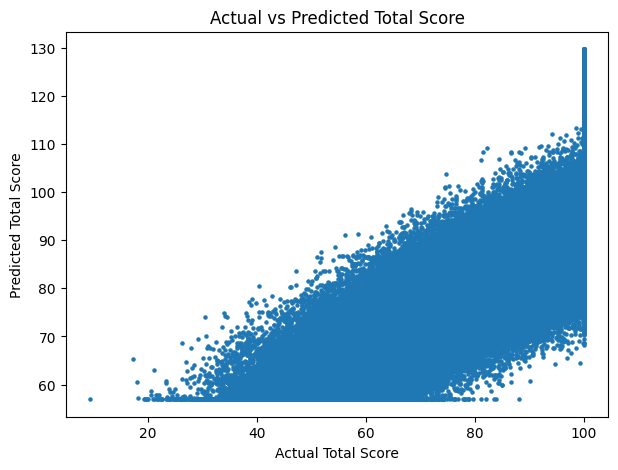

In [162]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, s=5)
plt.xlabel("Actual Total Score")
plt.ylabel("Predicted Total Score")
plt.title("Actual vs Predicted Total Score")
plt.show()

In [163]:
from sklearn.tree import DecisionTreeRegressor
tree_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)
tree_model.fit(x_train, y_train)
tree_pred = tree_model.predict(x_test)

In [164]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
tree_mae = mean_absolute_error(y_test, tree_pred)
tree_mse = mean_squared_error(y_test, tree_pred)
tree_rmse = np.sqrt(tree_mse)
tree_r2 = r2_score(y_test, tree_pred)
print("Decision Tree")
print("MAE :", tree_mae)
print("MSE :", tree_mse)
print("RMSE:", tree_rmse)
print("R²  :", tree_r2)

Decision Tree
MAE : 6.113304015669492
MSE : 67.58304918439205
RMSE: 8.220891021318312
R²  : 0.7161265993912844


In [165]:
depths = [2, 5, 10, 15, 20]
results = []
for depth in depths:
    tree = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )
    tree.fit(x_train, y_train)
    train_pred = tree.predict(x_train)
    test_pred = tree.predict(x_test)
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    results.append({
        "depth": depth,
        "train_r2": train_r2,
        "test_r2": test_r2
    })

results_df = pd.DataFrame(results)
print(results_df)

   depth  train_r2   test_r2
0      2  0.665269  0.667006
1      5  0.716697  0.717123
2     10  0.718897  0.716127
3     15  0.732720  0.701835
4     20  0.780335  0.645795


In [166]:
from sklearn.model_selection import cross_val_score
tree_cv = DecisionTreeRegressor(
    max_depth=5,
    random_state=42)
cv_scores = cross_val_score(
    tree_cv,
    x_train,
    y_train,
    cv=5,
    scoring="r2")
print("CV Scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())

CV Scores: [0.71686957 0.71457591 0.71553645 0.71743184 0.71779489]
Mean CV R²: 0.7164417329996501


In [167]:
tune_size = 100000
tune_idx = x_train.sample(
    n=tune_size,
    random_state=42
).index
x_tune = x_train.loc[tune_idx]
y_tune = y_train.loc[tune_idx]

In [168]:
param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 5]
}

In [169]:
from sklearn.model_selection import GridSearchCV
tree = DecisionTreeRegressor(random_state=42)
grid_search = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1)

In [170]:
grid_search.fit(x_tune, y_tune)
print("Best Parameters:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV R²: 0.7176578466130847


In [171]:
best_tree = grid_search.best_estimator_
best_tree

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [172]:
best_tree.fit(x_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [173]:
final_pred = best_tree.predict(x_test)

In [174]:
final_mae = mean_absolute_error(y_test, final_pred)
final_mse = mean_squared_error(y_test, final_pred)
final_rmse = np.sqrt(final_mse)
final_r2 = r2_score(y_test, final_pred)
print("Final Decision Tree")
print("MAE :", final_mae)
print("MSE :", final_mse)
print("RMSE:", final_rmse)
print("R²  :", final_r2)

Final Decision Tree
MAE : 6.108887769855384
MSE : 67.34585139277509
RMSE: 8.206451815052294
R²  : 0.7171229164343269


In [175]:
feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": best_tree.feature_importances_
})
feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False)
print(feature_importance)

                   Feature  Importance
0  weekly_self_study_hours         1.0
1    attendance_percentage         0.0
2      class_participation         0.0


In [176]:
import joblib

In [177]:
joblib.dump(best_tree, "student_score_model.pkl")

['student_score_model.pkl']

In [178]:
loaded_model = joblib.load("student_score_model.pkl")

In [179]:
test_prediction = loaded_model.predict(x_test.iloc[:5])
print(test_prediction)

[61.24137931 91.22005964 71.70614931 87.33174911 52.40866667]
